Профессия Data Science  
Блок 6. Математика в ML. Часть II  
**MATH&ML-10. Кластеризация и техники понижения размерности. Часть I**

---

## **✍ Оглавление:**
1. Введение
2. K-means
3. EM-алгоритм
4. K-Means и EM-алгоритм: практика
5. DBSCAN
6. Агломеративная иерархическая кластеризация

## **1. Введение**

**Кластеризация** — это задача группировки объектов на подмножества (кластеры) таким образом, чтобы объекты из одного кластера были более похожи друг на друга, чем на объекты из других кластеров, по какому-либо критерию.

## **2. K-means**

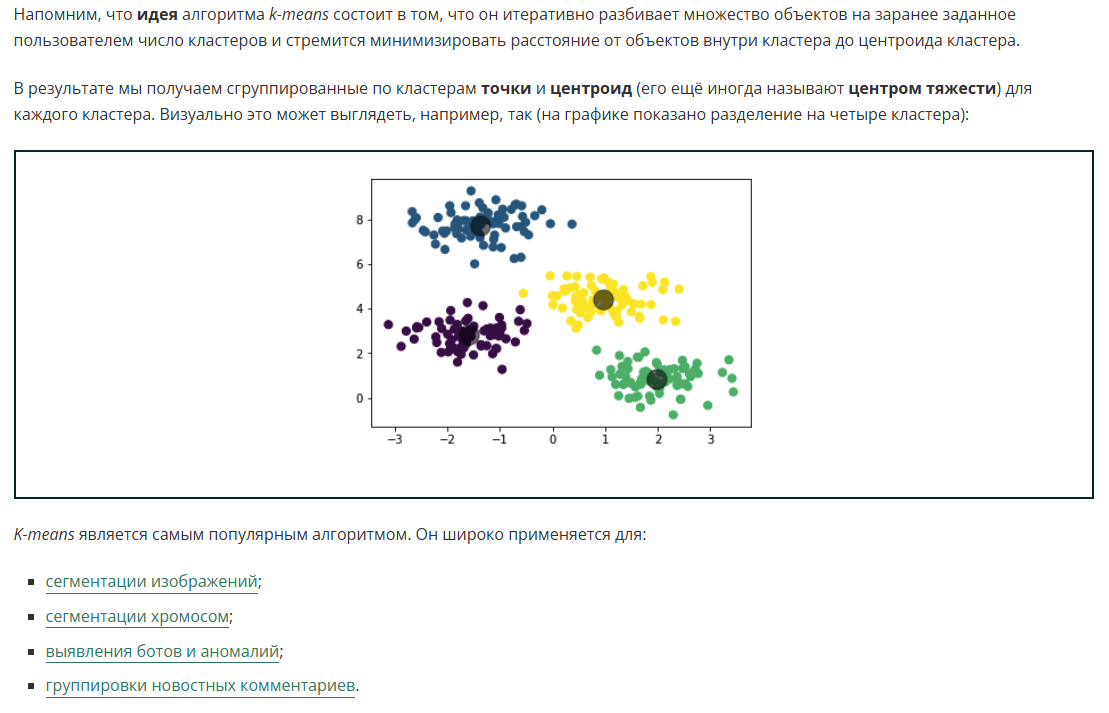

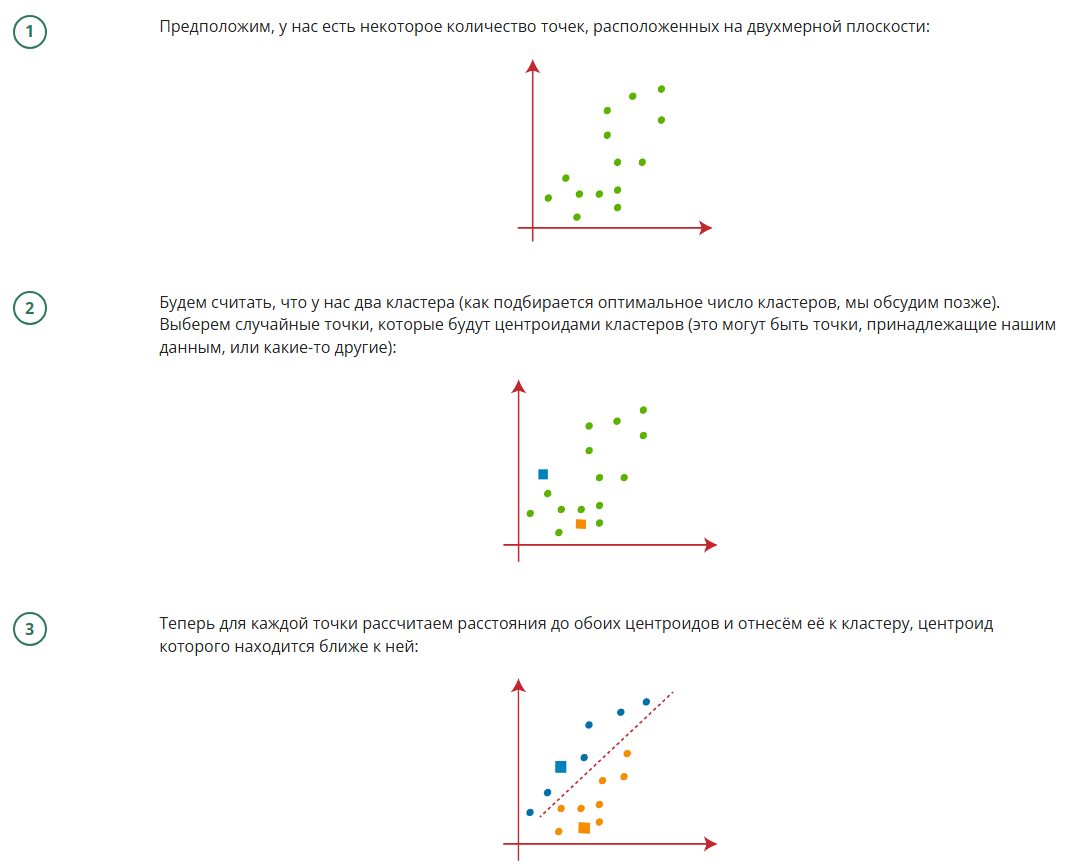

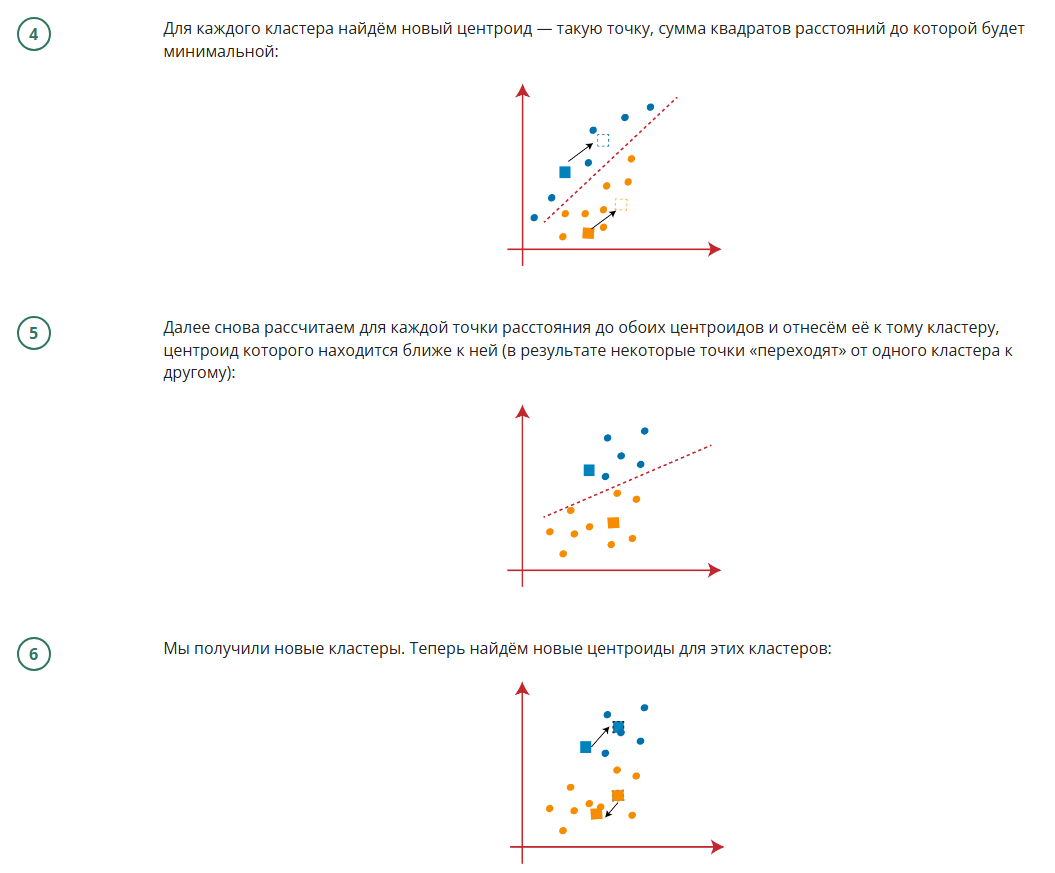

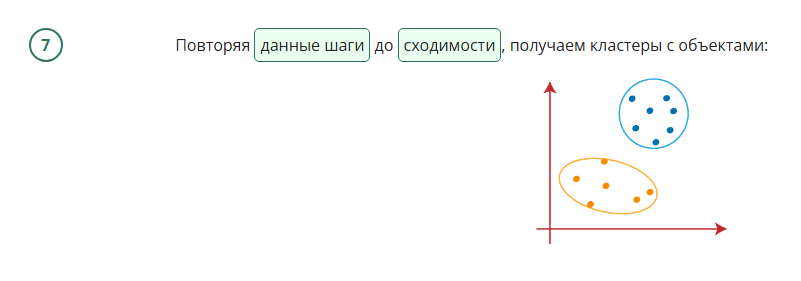

## **3. EM-алгоритм**

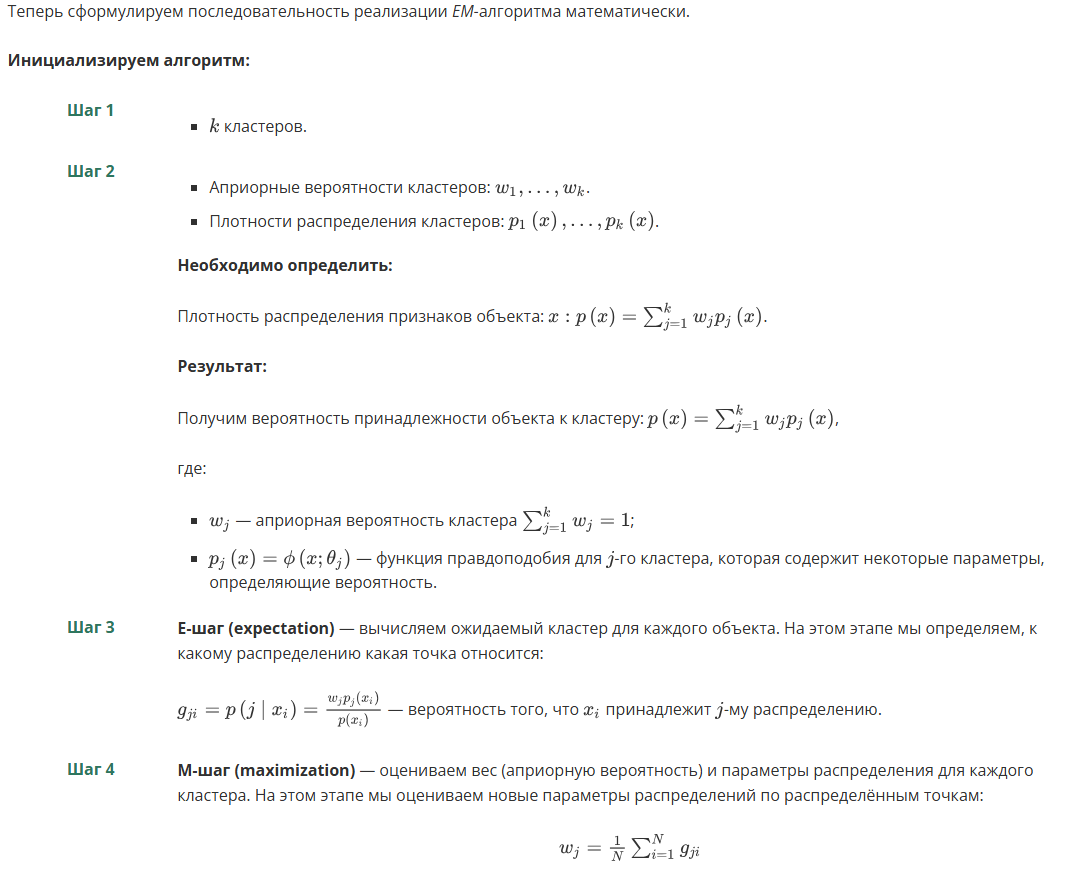

## **4. K-Means и EM-алгоритм: практика**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=0)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Загружаем исходные данные:
df_sns = pd.read_csv('snsdata.csv')
df_sns.head(3)

,gradyear,gender,age,friends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2006,M,18.982,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,F,18.801,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,2006,M,18.335,69,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [2]:
# Задание 4.1

df_sns = df_sns.iloc[:, 4:]
df_sns.shape

(30000, 36)

In [3]:
# Задание 4.2

X = df_sns.values
scaler = StandardScaler()
scaler.fit(X)
X_norm = scaler.transform(X)
X_norm[0][0]

-0.3322172643985876

In [4]:
# Задание 4.3

model = KMeans(n_clusters=9, random_state=42)
model.fit(X_norm)
model.inertia

AttributeError: 'KMeans' object has no attribute 'inertia'

In [ ]:
# Задание 4.4

df_sns.loc[:, 'label'] = model.labels_
df_sns.label.value_counts()

label
1    19599
2     4284
0     2201
4      941
3      902
5      851
8      754
7      467
6        1
Name: count, dtype: int64

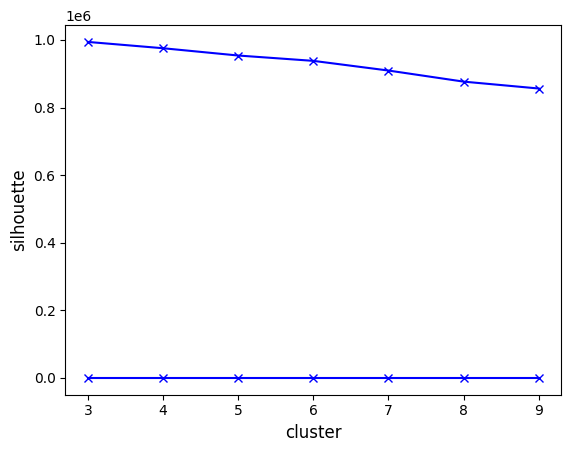

In [ ]:
# Задание 4.5

def get_inertia(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)
    k_means.fit(X)
    inertia = k_means.inertia_
    return inertia
 
inertia = []
for cluster_num in range(3, 10):
    inertia.append(get_inertia(cluster_num, X_norm))
 
plt.xlabel("cluster", fontsize=12)
plt.ylabel("inertia", fontsize=12)
plt.plot([i for i in range(3, 10)], inertia, 'xb-')
from sklearn.metrics import silhouette_score

def get_silhouette(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)
    k_means.fit(X)
    silhouette = silhouette_score(X, k_means.labels_, metric='euclidean')
    return silhouette

silhouettes = []
for i in range(3, 10):
    silhouettes.append(get_silhouette(i, X_norm))
    
plt.xlabel("cluster", fontsize=12)
plt.ylabel("silhouette", fontsize=12)
plt.plot([i for i in range(3, 10)], silhouettes, 'xb-')

In [ ]:
# Задание 4.6

top_list = []
for label, group in df.groupby('label'):
    means = group.iloc[:,:-1].mean().sort_values(ascending=False)
    top_5 = set(means.head(10).index)
    top_list.append(top_5)

set.intersection(*top_list)

KeyError: 'label'

In [ ]:
# Задание 4.7

from sklearn.mixture import GaussianMixture
model = GaussianMixture(n_components=3, random_state=42)
predictions = model.fit_predict(X)
np.unique(predictions, return_counts=True)

(array([0, 1, 2], dtype=int64), array([21744,  5219,  3037], dtype=int64))

In [ ]:
# Задание 4.8

a = np.where(predictions == 2)
df_sns.iloc[a]

NameError: name 'predictions' is not defined

## **5. DBSCAN**

Этот алгоритм хорошо подходит для ситуаций, когда необходимо выделить кластеры различной, порой довольно сложной формы. Такая задача достаточно часто возникает при анализе географических данных: например, при выделении кластеров пользователей по геометкам.

**Основная идея** этого алгоритма заключается в том, что объект  принадлежит кластеру, если находится достаточно близко ко многим объектам из этого кластера.

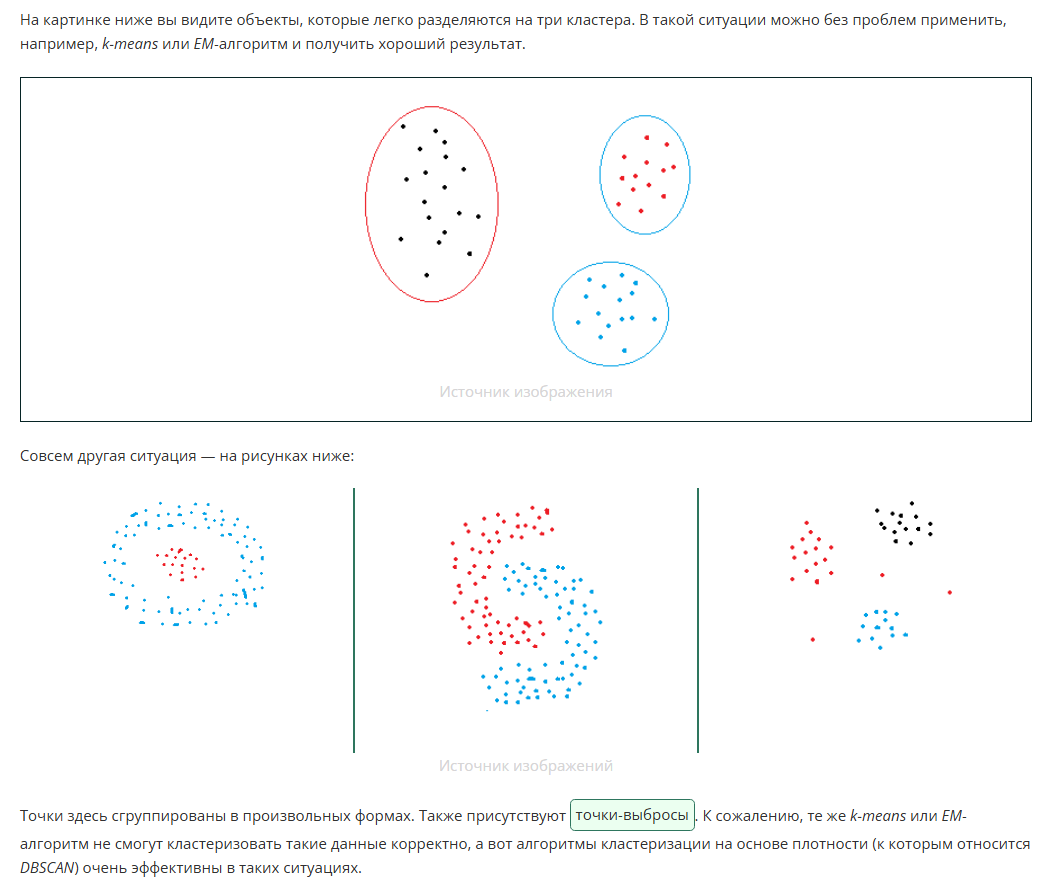

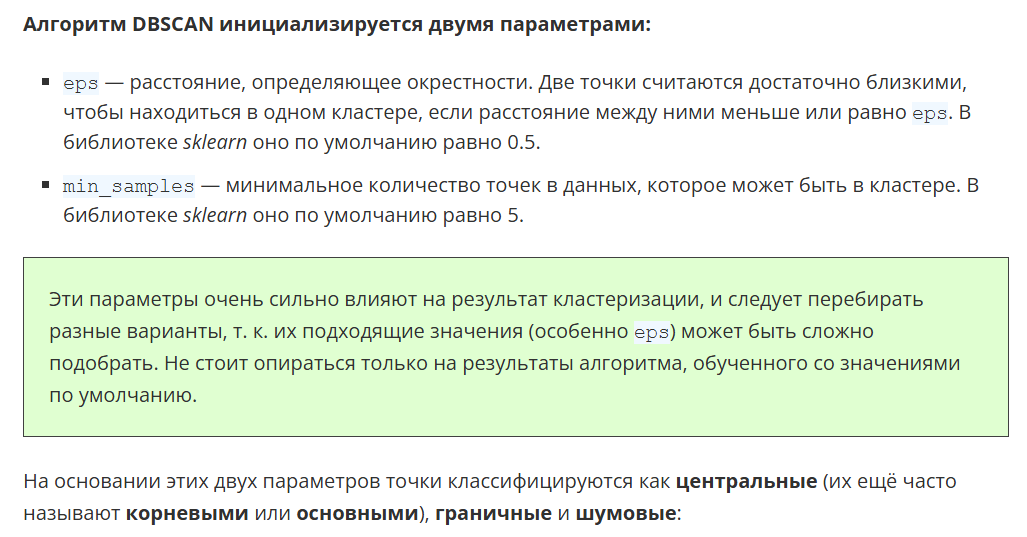

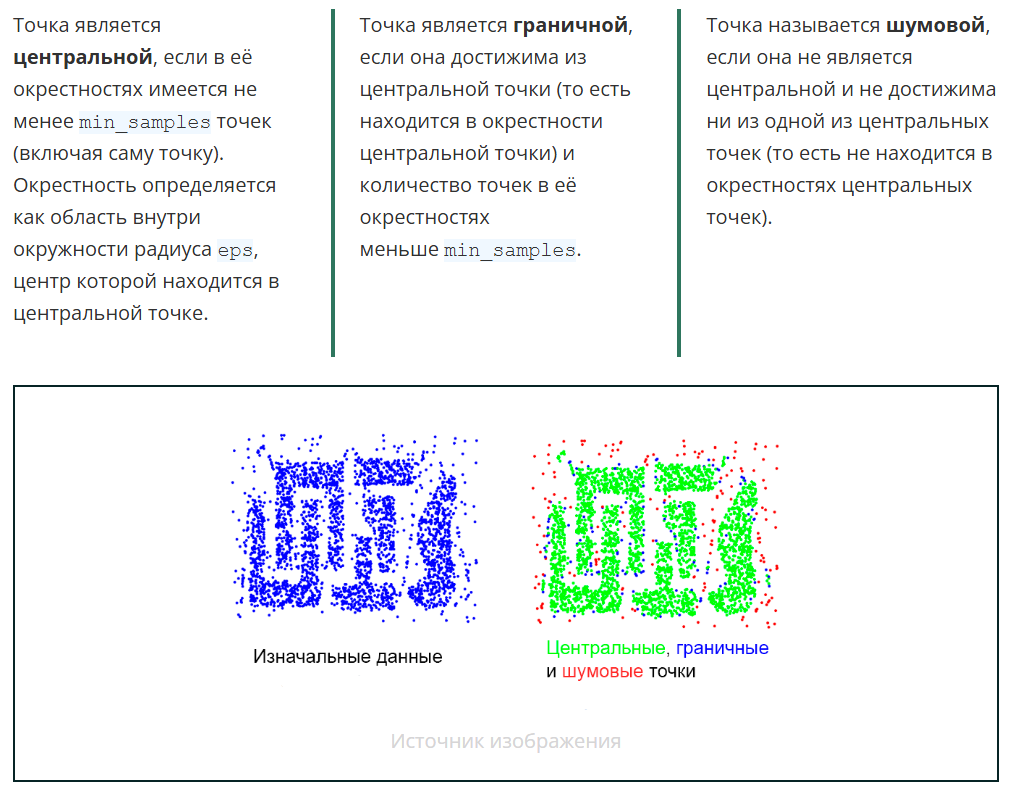

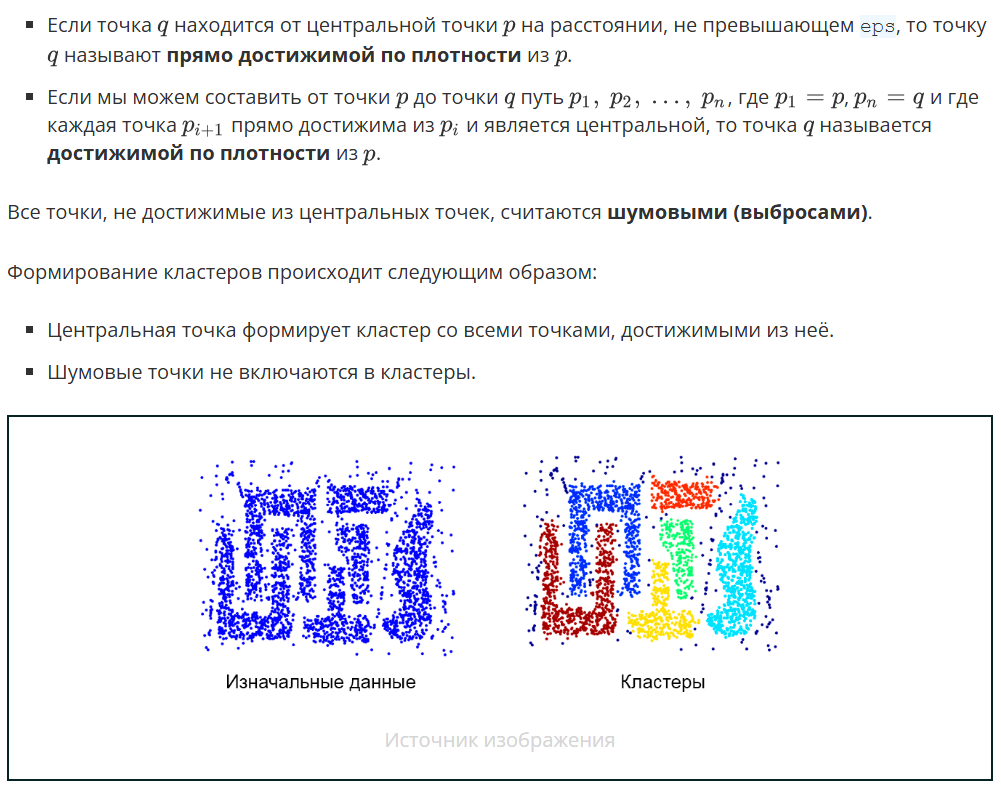

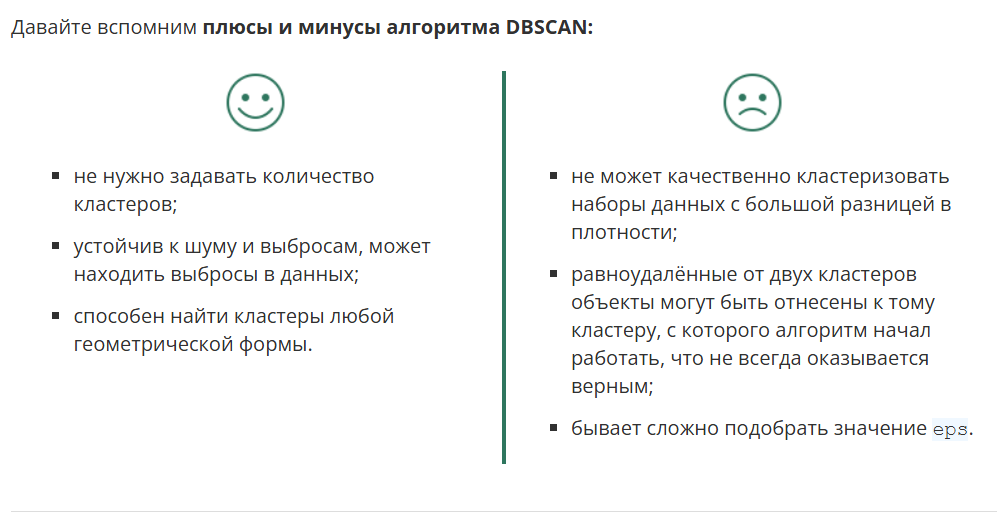

## **6. Агломеративная иерархическая кластеризация**

Иерархическая кластеризация — очень популярный метод кластеризации в силу простоты реализации и интерпретации. По ходу её работы создаются кластеры, организованные в иерархическую структуру. Эту структуру можно визуализировать с помощью древовидной диаграммы, называемой дендрограммой.

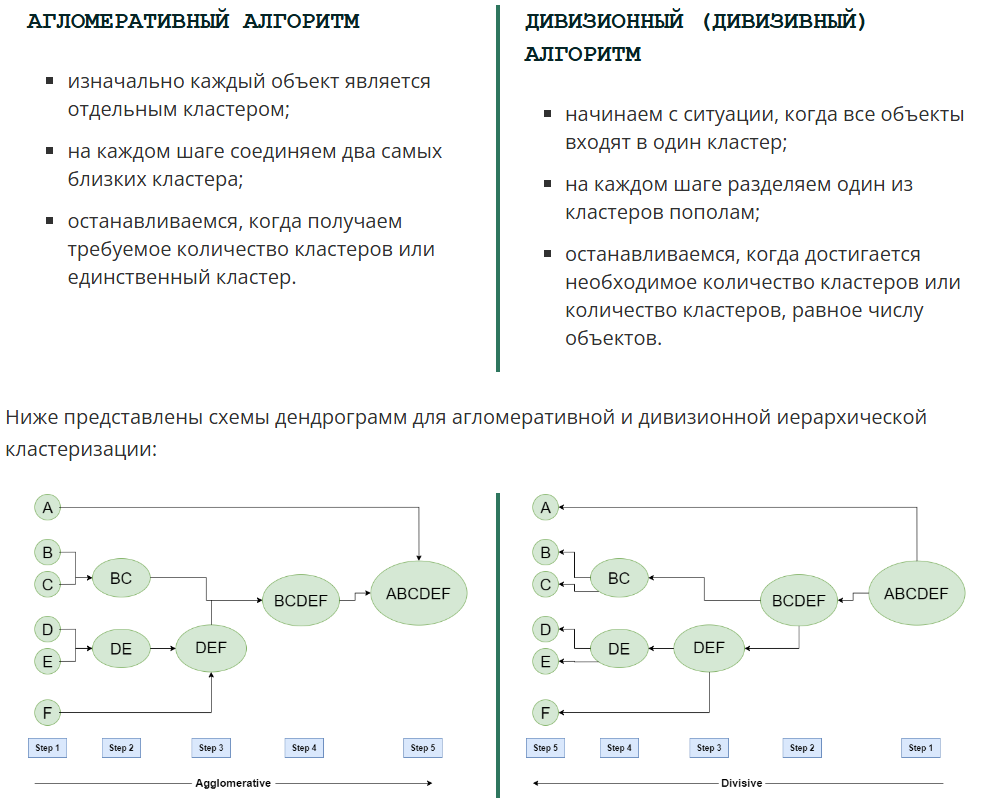

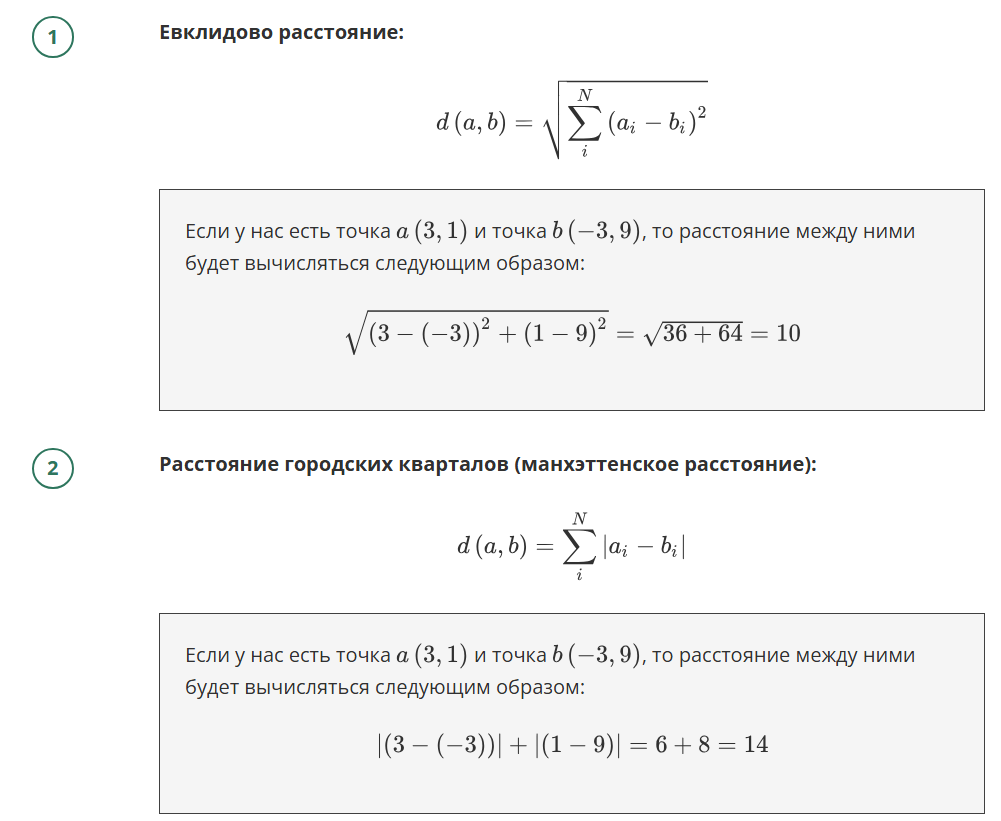

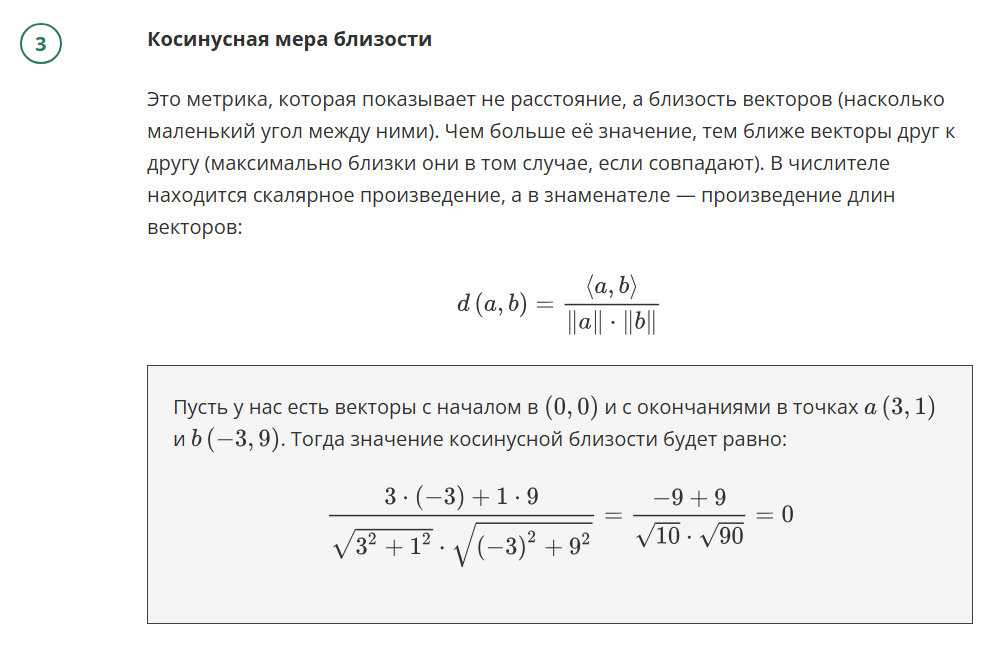

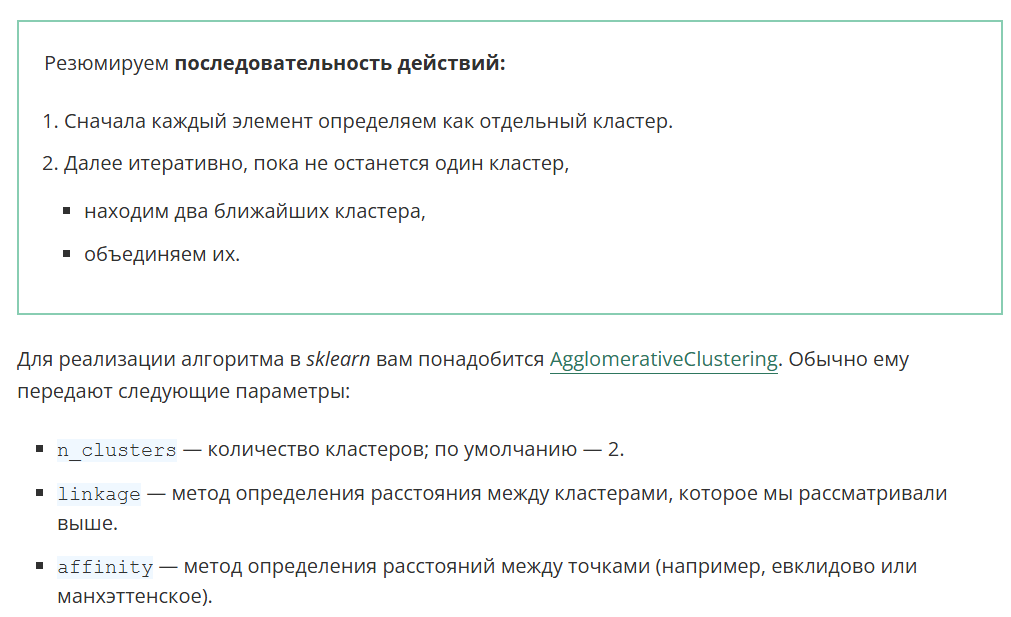

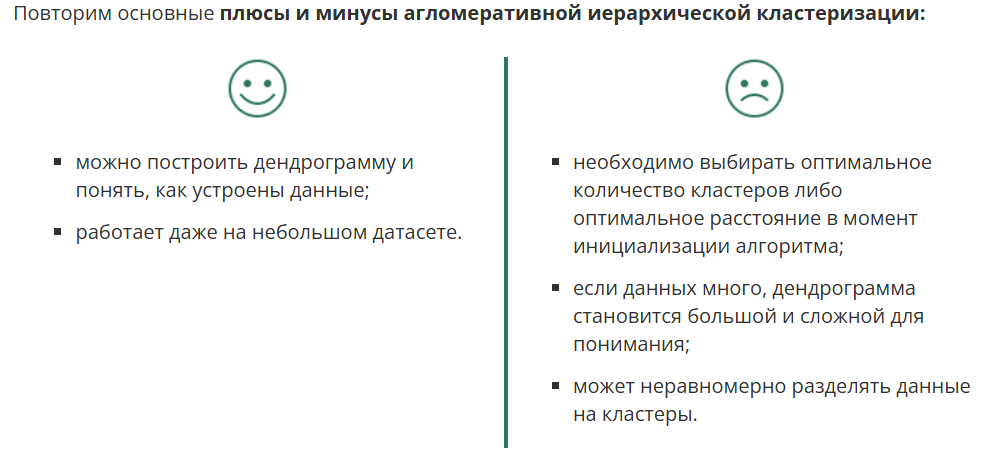

In [6]:
# Загружаем исходные данные:
df = pd.read_csv('CC GENERAL.csv')
df.head(3)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.0,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12


In [7]:
# Задание 7.2

df.isnull().sum().sum()

314

In [8]:
# Задание 7.3

df.fillna(df.mean(numeric_only=True), inplace = True)
df['MINIMUM_PAYMENTS'].mean(numeric_only=True)

864.2065423050827

In [9]:
# Задание 7.4

df.drop('CUST_ID', axis = 1, inplace = True)
X = df.values
scaler = StandardScaler()
scaler.fit(X)
X_norm = scaler.transform(X)
X_norm[0][0]

-0.7319893664465486

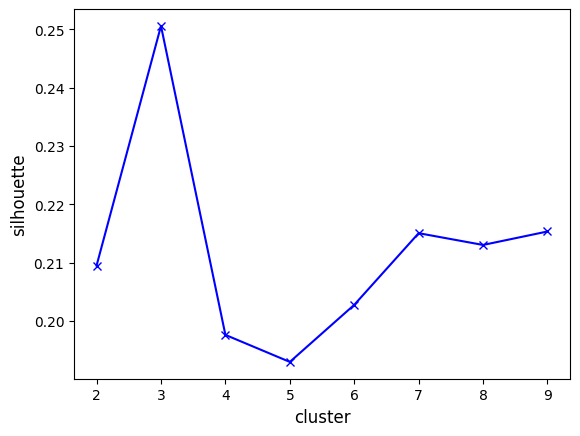

In [10]:
# Задание 7.5

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def get_silhouette(cluster_num, df):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42, init='random')
    k_means.fit(df)
    silhouette = silhouette_score(df, k_means.labels_, metric='euclidean')
    return silhouette
from sklearn.metrics import silhouette_score
silhouettes = []
for i in range(2, 10):
    silhouettes.append(get_silhouette(i ,X_norm))
    
plt.xlabel("cluster", fontsize=12)
plt.ylabel("silhouette", fontsize=12)
plt.plot([i for i in range(2, 10)], silhouettes, 'xb-');

In [11]:
# Задание 7.6

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, init='random')
kmeans.fit(X_norm)
df.loc[:, 'label'] = kmeans.labels_
df.label.value_counts().min()

1235

In [13]:
# Задание 7.7

from sklearn.cluster import DBSCAN
db = DBSCAN()
db.fit(X_norm)
clusters = db.labels_
len(set(clusters)) - (1 if -1 in clusters else 0)

38

In [14]:
# Задание 7.8

siliuette_list_dbscan = []
 
for eps in np.arange(0.1,3,0.2):
    for min_sample in range(1,20,4):
        dbscan = DBSCAN(eps=eps, min_samples=min_sample)
        dbscan.fit(X_norm)
        sil_score = silhouette_score(X_norm, dbscan.labels_, metric='euclidean')
        siliuette_list_dbscan.append((eps, min_sample, sil_score, len(set(dbscan.labels_))) )
df_dbscan = pd.DataFrame(siliuette_list_dbscan, columns=['eps', 'min_samples', 'sil_score', 'number_of_clusters'])
df_dbscan.sort_values(by = 'sil_score')

,eps,min_samples,sil_score,number_of_clusters
11,0.5,5,-0.443701,39
16,0.7,5,-0.438837,29
6,0.3,5,-0.424475,42
7,0.3,9,-0.404209,15
30,1.3,1,-0.399305,1536
...,...,...,...,...
74,2.9,17,0.591924,2
66,2.7,5,0.592182,2
73,2.9,13,0.595399,2
72,2.9,9,0.603811,2


In [19]:
# Задание 7.9
import numpy as np
from sklearn.cluster import AgglomerativeClustering
siliuette_list_hierarchical = []
 
for cluster in range(3,10,1):
        agglomerative = AgglomerativeClustering(affinity='euclidean',n_clusters=cluster).fit_predict(X_norm)
        sil_score = silhouette_score(X_norm, agglomerative, metric='euclidean')
        siliuette_list_hierarchical.append((cluster, sil_score,len(set(agglomerative)) ) )
        
df_hierarchical = pd.DataFrame(siliuette_list_hierarchical, columns=['cluster', 'sil_score','number_of_clusters'])
 
 
df_hierarchical.sort_values(by = 'sil_score')

TypeError: __init__() got an unexpected keyword argument 'affinity'

In [20]:
# Задание 7.10

model = AgglomerativeClustering(affinity='euclidean', n_clusters=6).fit(X_norm)
df['cluster_id'] = model.labels_
df['cluster_id'].value_counts()

TypeError: __init__() got an unexpected keyword argument 'affinity'

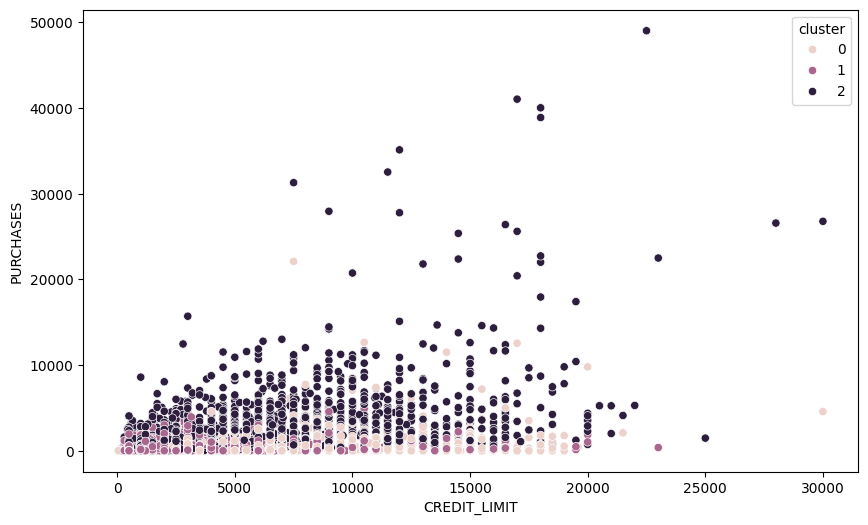

In [21]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_norm)
df['cluster'] = kmeans.labels_
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='CREDIT_LIMIT', y='PURCHASES', hue='cluster')
plt.show()